# Projekt 3 - Oświetlenie i cienie trójkątów

# Opis projektu

Celem projektu jest wygenerowanie obrazów i animacji trzech trójkątów 3D rzutowanych równolegle na płaszczyznę OXY, z modelami oświetlenia Lamberta i Phonga oraz z uwzględnieniem wzajemnego zacieniania.

W dużym stopniu wykorzystuję kod z poprzednich laboratoriów ale wprowadzam kilka modyfikacji wymaganych przez treść projektu.

## Scena

Mamy trzy trójkąty o współrzędnych narożników (x, y, z):

- **Trójkąt A:** (-22, 0, 58), (11, 19, 58), (0, 0, 26)
- **Trójkąt B:** (-22, 0, 58), (11, -19, 58), (0, 0, 26)
- **Trójkąt C:** (3, 19, 48), (3, -19, 48), (-8, 0, 16)

Dwa pierwsze trójkąty mają wspólne narożniki, więc w obrazie mogą występować ich przecięcia.

Każdy trójkąt ma inne współczynniki odbicia kolorów bazowych RGB (ε):

| Trójkąt | ε_R | ε_G | ε_B |
|---------|-----|-----|-----|
| A       | 1   | 0.5 | 0.25|
| B       | 0.25| 1   | 0.5 |
| C       | 0.25| 0.5 | 1   |

## Parametry obrazu i oświetlenia

- Rozdzielczość: **640×480**, rozmiar piksela: **0.1×0.1**
- Światło tła: **I_amb = [100, 100, 100]**
- Punktowe źródło światła: **I_max = [1000, 1000, 1000]**, pozycja **p_light = [-5, -5, -28]**
- Spadek natężenia: `I_max / (1 + 0.001 * ||p - p_light||^2)`
- Model Phonga: oko w **[10, 5, 40]**, współczynnik połysku **m = 15**

## Problemy i modyfikacje względem laboratoriów

Największą różnicą względem labów jest to, że projekt wymaga **kolorowego** oświetlenia RGB, a moje funkcje z laboratoriów korzystają z pojedynczych wartości natężenia światła i nie obsługują kolorów trójkątów.

Dlatego:
- rozszerzam klasy `Light` i `AMBIENT_LIGHT` tak, by operowały na wektorach RGB,
- w `Triangle` ustawiam `epsilon` jako wektor `[ε_R, ε_G, ε_B]` zamiast skalarnej jedynki,
- końcowy kolor piksela liczę osobno dla każdego kanału i na końcu obcinam do `[0, 255]`.

# Import bibliotek i definicja potrzebnych funkcji

Wykorzystuje kod z laboratoriów (z powyższymi modyfikacjami):

- klasy `Point`, `Triangle`, `Light`
- `mat2pix`, `pix2mat`, `distance2plane`
- `DrawTriangleWithLambert`
- `DrawTriangleWithPhong`
- `distance2plane` 
- `plane`
- `rzucanieCienia`

Dodaję też funkcję, która w łatwy sposób pozwoli mi generować różne sceny bez potrzeby powtarzania kodu.
`render_scene` — w osobnej komórce poniżej.

Aby skrócić kod, do maskowania trójkątów nadal korzystam z `cv2.fillPoly`, tak jak na laboratoriach.

## Problemy optymalizacyjne

Z racji na duży przeskok w ilości obliczeń: 3 kanały zamiast 1, więcej trójkątów, a każdy rzuca cień na wszystkie inne. Ruchome i kolorowe światło, musiałem wprowadzić sporo usprawnień optymalizacyjnych. Bez nich generowanie animacji trwało zamiast około 10 sekund, ponad godzinę.

Optymalizacje zostały opisane w komentarzach #optymalizacja:

In [1]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt


class Point:
    def __init__(self, x, y, z):
        self.coords = np.array([x, y, z], dtype=float)

    def __getitem__(self, index):
        return self.coords[index]


class Triangle:
    def __init__(self, p1: Point, p2: Point, p3: Point, epsilon=None):
        self.p1 = p1
        self.p2 = p2
        self.p3 = p3
        self.epsilon = np.array(epsilon if epsilon is not None else [1, 1, 1], dtype=float)


class Light:
    def __init__(self, position: Point, intensity):
        self.position = position
        self.intensity = np.asarray(intensity, dtype=float)


def mat2pix(m, n, dx, dy, x, y):
    transformMatrix = np.array([[1 / dx, 0, 0.5 * m], [0, -1 / dy, 0.5 * n], [0, 0, 1]])
    pixelCoords = np.dot(transformMatrix, np.array([x, y, 1]))
    px = int(round(pixelCoords[0] / pixelCoords[2]))
    py = int(round(pixelCoords[1] / pixelCoords[2]))
    return px, py


def pix2mat(m, n, dx, dy, u, v):
    transformMatrix = np.array(
        [[dx, 0, -0.5 * m * dx], [0, -dy, 0.5 * n * dy], [0, 0, 1]]
    )
    mathCords = np.dot(transformMatrix, np.array([u, v, 1]))
    return (mathCords[0] / mathCords[2]), (mathCords[1] / mathCords[2])


def distance2plane(point, A, b, c, d, DirX=None, DirY=None, DirZ=None):
    if DirX is not None and DirY is not None and DirZ is not None:
        dir_vector = np.array([DirX, DirY, DirZ], dtype=float)
        dir_vector /= np.linalg.norm(dir_vector)
        point = np.asarray(point, dtype=float)
        numerator = A * point[0] + b * point[1] + c * point[2] + d
        denominator = A * dir_vector[0] + b * dir_vector[1] + c * dir_vector[2]
        if np.isclose(denominator, 0.0):
            raise ValueError(
                "Wektor kierunkowy jest równoległy do płaszczyzny, rzutowanie jest niemożliwe."
            )
        t = -numerator / denominator
        plane_point = point + t * dir_vector
        return float(t), plane_point

    point = np.asarray(point, dtype=float)
    x, y, z = point
    mianownik = A**2 + b**2 + c**2
    if np.isclose(mianownik, 0.0):
        raise ValueError("Nieprawidłowa płaszczyzna.")
    licznik = A * x + b * y + c * z + d
    t = -licznik / mianownik
    plane_point = np.array([x + t * A, y + t * b, z + t * c])
    distance = np.abs(licznik) / np.sqrt(mianownik)
    return float(distance), plane_point


def plane(Triangle_obj):
    p1 = np.asarray(Triangle_obj.p1.coords, dtype=float)
    p2 = np.asarray(Triangle_obj.p2.coords, dtype=float)
    p3 = np.asarray(Triangle_obj.p3.coords, dtype=float)
    normal = np.cross(p2 - p1, p3 - p1)
    if np.allclose(normal, 0.0):
        raise ValueError("Punkty są współliniowe.")
    A, b, c = normal
    d = -np.dot(normal, p1)
    return float(A), float(b), float(c), float(d)


def _triangle_pixel_coords(triangle, res_x, res_y, dx, dy):
    return [
        mat2pix(res_x, res_y, dx, dy, triangle.p1[0], triangle.p1[1]),
        mat2pix(res_x, res_y, dx, dy, triangle.p2[0], triangle.p2[1]),
        mat2pix(res_x, res_y, dx, dy, triangle.p3[0], triangle.p3[1]),
    ]


def _triangle_bbox(triangle_pixel_coords, res_x, res_y):
    xs = [p[0] for p in triangle_pixel_coords]
    ys = [p[1] for p in triangle_pixel_coords]
    return (
        max(0, min(ys)),
        min(res_y - 1, max(ys)),
        max(0, min(xs)),
        min(res_x - 1, max(xs)),
    )


def _clip_rgb(color):
    return np.clip(color, 0, 255).astype(np.uint8)


def _pix2mat_fast(res_x, res_y, dx, dy, u, v):
    # optymalizacja: to samo co pix2mat(res_x, res_y, dx, dy, u, v), bez mnożenia macierzy
    return dx * u - 0.5 * res_x * dx, -dy * v + 0.5 * res_y * dy


def _distance2plane_z_ray(X, Y, A, B, C, D):
    # optymalizacja: to samo co distance2plane([X, Y, 0], A, B, C, D, 0, 0, 1)
    t = -(A * X + B * Y + D) / C
    return t, np.array([X, Y, t], dtype=float)


def _distance2plane_ray(origin, direction, A, B, C, D):
    # optymalizacja: to samo co distance2plane(origin, A, B, C, D, direction[0], direction[1], direction[2])
    numerator = A * origin[0] + B * origin[1] + C * origin[2] + D
    denominator = (
        A * direction[0] + B * direction[1] + C * direction[2]
    )
    if np.isclose(denominator, 0.0):
        raise ValueError(
            "Wektor kierunkowy jest równoległy do płaszczyzny, rzutowanie jest niemożliwe."
        )
    t = -numerator / denominator
    return t, origin + t * direction


def DrawTriangleWithLambert(
    Image, Triangle_obj, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
):
    imgCopy = np.zeros_like(Image)
    triangle_pixel_coords = _triangle_pixel_coords(
        Triangle_obj, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY
    )
    # optymalizacja: maska 1-kanałowa zamiast fillPoly na całym obrazie RGB
    mask = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X), dtype=np.uint8)
    cv2.fillPoly(mask, [np.array(triangle_pixel_coords)], 255)
    # optymalizacja: liczę oświetlenie tylko w prostokącie otaczającym trójkąt, nie na całym obrazie
    y_min, y_max, x_min, x_max = _triangle_bbox(
        triangle_pixel_coords, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y
    )

    triangle_normal = np.cross(
        Triangle_obj.p2.coords - Triangle_obj.p1.coords,
        Triangle_obj.p3.coords - Triangle_obj.p1.coords,
    )
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle_obj.p1.coords)
    epsilon = Triangle_obj.epsilon
    ambient = np.asarray(AMBIENT_LIGHT, dtype=float)

    for y in range(y_min, y_max + 1):
        for x in range(x_min, x_max + 1):
            if mask[y, x] != 255:
                continue

            X_world, Y_world = _pix2mat_fast(
                ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y
            )
            _, plane_point = _distance2plane_z_ray(X_world, Y_world, A, B, C, D)

            final_intensity = ambient * epsilon
            for light in Lights:
                light_vector = light.position.coords - plane_point
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance
                angle_cos = np.dot(triangle_normal, light_vector_normalized)
                attenuation = light.intensity / (1 + 0.001 * light_distance**2)
                final_intensity += epsilon * attenuation * max(angle_cos, 0)

            imgCopy[y, x] = _clip_rgb(final_intensity)

    return imgCopy


def DrawTriangleWithPhong(
    Image,
    Triangle_obj,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
    eye_position,
    specular_m=15,
):
    imgCopy = np.zeros_like(Image)
    triangle_pixel_coords = _triangle_pixel_coords(
        Triangle_obj, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY
    )
    # optymalizacja: maska 1-kanałowa zamiast fillPoly na całym obrazie RGB
    mask = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X), dtype=np.uint8)
    cv2.fillPoly(mask, [np.array(triangle_pixel_coords)], 255)
    # optymalizacja: liczę oświetlenie tylko w prostokącie otaczającym trójkąt, nie na całym obrazie
    y_min, y_max, x_min, x_max = _triangle_bbox(
        triangle_pixel_coords, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y
    )

    triangle_normal = np.cross(
        Triangle_obj.p2.coords - Triangle_obj.p1.coords,
        Triangle_obj.p3.coords - Triangle_obj.p1.coords,
    )
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle_obj.p1.coords)
    epsilon = Triangle_obj.epsilon
    ambient = np.asarray(AMBIENT_LIGHT, dtype=float)
    eye_coords = eye_position.coords

    for y in range(y_min, y_max + 1):
        for x in range(x_min, x_max + 1):
            if mask[y, x] != 255:
                continue

            X_world, Y_world = _pix2mat_fast(
                ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y
            )
            _, plane_point = _distance2plane_z_ray(X_world, Y_world, A, B, C, D)

            final_intensity = ambient * epsilon
            for light in Lights:
                light_vector = light.position.coords - plane_point
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance
                angle_cos = np.dot(triangle_normal, light_vector_normalized)
                attenuation = light.intensity / (1 + 0.001 * light_distance**2)

                lambert_diffuse = attenuation * max(angle_cos, 0)
                reflection_vector = (
                    2 * angle_cos * triangle_normal - light_vector_normalized
                )
                eye_vector = eye_coords - plane_point
                eye_vector_normalized = eye_vector / np.linalg.norm(eye_vector)
                specular_dot = np.dot(reflection_vector, eye_vector_normalized)
                specular_contribution = attenuation * (max(specular_dot, 0) ** specular_m)

                final_intensity += epsilon * (lambert_diffuse + specular_contribution)

            imgCopy[y, x] = _clip_rgb(final_intensity)

    return imgCopy


def rzucanieCienia(
    Image,
    Triangle_obj,
    Other_Triangles,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
    geometry,
):
    imgCopy = Image
    # optymalizacja: modyfikuję obraz w miejscu zamiast robić kopię całej bitmapy
    triangle_idx = next(i for i, t in enumerate(Other_Triangles) if t is Triangle_obj)
    # optymalizacja: równanie płaszczyzny biorę z danych policzonych w render_scene zamiast wywoływać plane() ponownie
    A, B, C, D = geometry["planes"][triangle_idx]
    shadow_color = _clip_rgb(np.asarray(AMBIENT_LIGHT, dtype=float) * Triangle_obj.epsilon)
    light_pos = Lights[0].position.coords
    # optymalizacja: sprawdzam cienie tylko na pikselach narysowanego trójkąta
    pixel_ys, pixel_xs = np.where(imgCopy[:, :, 0] > 0)
    # optymalizacja: dane drugich trójkątów zbieram raz przed pętlą po pikselach
    other_items = [
        (idx, geometry["planes"][idx], geometry["shadow_data"][idx])
        for idx, other_triangle in enumerate(Other_Triangles)
        if other_triangle is not Triangle_obj
    ]

    for y, x in zip(pixel_ys, pixel_xs):
        X_world, Y_world = _pix2mat_fast(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y
        )
        _, plane_point = _distance2plane_z_ray(X_world, Y_world, A, B, C, D)
        light_vector = plane_point - light_pos
        light_distance = np.linalg.norm(light_vector)
        light_vector /= light_distance

        for idx, plane_eq, geom in other_items:
            A2, B2, C2, D2 = plane_eq
            distance, _ = _distance2plane_ray(light_pos, light_vector, A2, B2, C2, D2)
            if 0 < distance < light_distance:
                hit_point = light_pos + distance * light_vector
                p1 = geom["p1"]
                n = geom["n"]
                d1 = np.dot(n, np.cross(geom["e12"], hit_point - p1))
                d2 = np.dot(n, np.cross(geom["e23"], hit_point - geom["p2"]))
                d3 = np.dot(n, np.cross(geom["e31"], hit_point - geom["p3"]))
                if (d1 >= 0 and d2 >= 0 and d3 >= 0) or (
                    d1 <= 0 and d2 <= 0 and d3 <= 0
                ):
                    imgCopy[y, x] = shadow_color
                    break

    return imgCopy


def merge_with_zbuffer(triangle_images, triangles, res_x, res_y, dx, dy, geometry):
    image = np.zeros((res_y, res_x, 3), dtype=np.uint8)
    # optymalizacja: z-buffer liczę tylko tam, gdzie któryś trójkąt ma już narysowany piksel
    occupied = np.zeros((res_y, res_x), dtype=bool)
    for triangle_image in triangle_images:
        occupied |= triangle_image[:, :, 0] > 0
    pixel_ys, pixel_xs = np.where(occupied)

    for y, x in zip(pixel_ys, pixel_xs):
        min_distance = float("inf")
        X_world, Y_world = _pix2mat_fast(res_x, res_y, dx, dy, x, y)
        for idx, triangle in enumerate(triangles):
            if triangle_images[idx][y, x, 0] == 0:
                continue
            # optymalizacja: równanie płaszczyzny biorę z danych policzonych w render_scene
            A, B, C, D = geometry["planes"][idx]
            distance, _ = _distance2plane_z_ray(X_world, Y_world, A, B, C, D)
            if distance < min_distance:
                min_distance = distance
                image[y, x] = triangle_images[idx][y, x]

    return image

# Konfiguracja sceny

Parametry obrazu, trójkąty i oświetlenie z treści projektu.

In [2]:
ROZDZIELCZOSC_X = 640
ROZDZIELCZOSC_Y = 480
DX = 0.1
DY = 0.1
AMBIENT_LIGHT = np.array([100, 100, 100], dtype=float)
LIGHT_INTENSITY = np.array([1000, 1000, 1000], dtype=float)
EYE_POSITION = Point(10, 5, 40)
SPECULAR_M = 15

Triangles = [
    Triangle(Point(-22, 0, 58), Point(11, 19, 58), Point(0, 0, 26), [1, 0.5, 0.25]),
    Triangle(Point(-22, 0, 58), Point(11, -19, 58), Point(0, 0, 26), [0.25, 1, 0.5]),
    Triangle(Point(3, 19, 48), Point(3, -19, 48), Point(-8, 0, 16), [0.25, 0.5, 1]),
]

# Funkcja `render_scene` do generowania obrazu sceny

Funkcja `render_scene` składa w jednym miejscu cały pipeline renderowania z **Lab10**, żeby nie powtarzać tych samych kroków w każdym zadaniu i przy każdej klatce animacji.

Wewnątrz funkcji wykonuję trzy etapy:

1. Dla każdego trójkąta osobno liczę oświetlenie — wywołuję `DrawTriangleWithLambert` albo `DrawTriangleWithPhong` (w zależności od parametru `model`).
2. Na każdym z tych obrazów nakładam cienie funkcją `rzucanieCienia`.
3. Łączę wyniki w jeden obraz za pomocą `merge_with_zbuffer` — dla każdego piksela wybieram trójkąt leżący najbliżej obserwatora.

Dzięki temu w zadaniach wystarczy podać listę świateł i model oświetlenia. Na początku `render_scene` liczę raz dane zależne tylko od geometrii sceny i przekazuję je do funkcji z labów.

Ta sama funkcja obsługuje zarówno statyczne obrazy z części I, jak i kolejne klatki animacji z części II — w animacji zmienia się tylko pozycja światła przekazywana w `lights`.

In [3]:
def render_scene(lights, model="lambert", eye_position=EYE_POSITION):
    # optymalizacja: równania płaszczyzn i dane do cieni liczę raz — geometria sceny się nie zmienia
    planes = [plane(t) for t in Triangles]
    shadow_data = []
    for triangle in Triangles:
        p1 = triangle.p1.coords
        p2 = triangle.p2.coords
        p3 = triangle.p3.coords
        n = np.cross(p2 - p1, p3 - p1)
        if np.allclose(n, 0.0):
            n = np.zeros(3)
        shadow_data.append(
            {
                "p1": p1,
                "p2": p2,
                "p3": p3,
                "e12": p2 - p1,
                "e23": p3 - p2,
                "e31": p1 - p3,
                "n": n,
            }
        )
    geometry = {"planes": planes, "shadow_data": shadow_data}

    empty = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)
    triangle_images = []

    for triangle in Triangles:
        if model == "lambert":
            triangle_images.append(
                DrawTriangleWithLambert(
                    empty,
                    triangle,
                    lights,
                    ROZDZIELCZOSC_X,
                    ROZDZIELCZOSC_Y,
                    DX,
                    DY,
                    AMBIENT_LIGHT,
                )
            )
        else:
            triangle_images.append(
                DrawTriangleWithPhong(
                    empty,
                    triangle,
                    lights,
                    ROZDZIELCZOSC_X,
                    ROZDZIELCZOSC_Y,
                    DX,
                    DY,
                    AMBIENT_LIGHT,
                    eye_position,
                    SPECULAR_M,
                )
            )

    for idx, triangle in enumerate(Triangles):
        triangle_images[idx] = rzucanieCienia(
            triangle_images[idx],
            triangle,
            Triangles,
            lights,
            ROZDZIELCZOSC_X,
            ROZDZIELCZOSC_Y,
            DX,
            DY,
            AMBIENT_LIGHT,
            geometry,
        )

    return merge_with_zbuffer(
        triangle_images, Triangles, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, geometry
    )

# Część I - Zadanie 1: obraz z modelem oświetlenia Lamberta

# Omówienie wyniku - Lambert

Na obrazie widać trzy trójkąty o różnych kolorach bazowych. Ciemniejsze fragmenty odpowiadają obszarom zacienionym przez inne trójkąty - wtedy zostaje tylko światło tła `I_amb`.

W miejscach przecięć poprawnie wygrywa trójkąt bliższy obserwatorowi, dzięki z-buforowi z labu 10.

Czas renderowania: 13.13 s


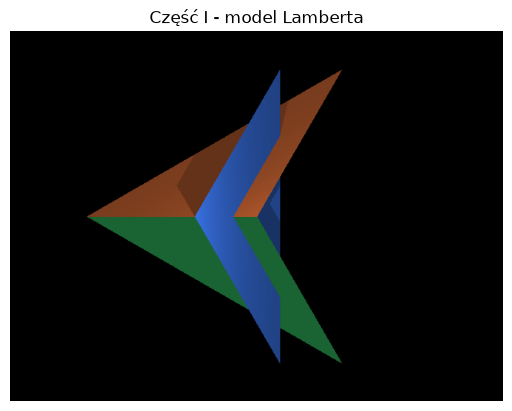

In [4]:
lights_static = [Light(Point(-5, -5, -28), LIGHT_INTENSITY)]

t0 = time.perf_counter()
image_lambert = render_scene(lights_static, model="lambert")
print(f"Czas renderowania: {time.perf_counter() - t0:.2f} s")

plt.imshow(image_lambert)
plt.axis("off")
plt.title("Część I - model Lamberta")
plt.savefig("lambert.png", bbox_inches="tight", pad_inches=0)
plt.show()

# Część I - Zadanie 2: obraz z modelem oświetlenia Phonga

# Omówienie wyniku - Phong

W porównaniu z obrazem Lamberta widać wyraźniejsze jasne refleksy. Cienie i przecięcia trójkątów wyglądają tak samo jak w zadaniu 1, bo algorytm `rzucanieCienia` jest niezależny od modelu oświetlenia powierzchni.

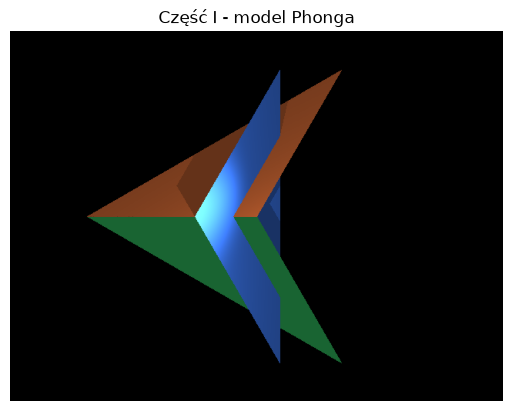

In [5]:
image_phong = render_scene(lights_static, model="phong")
plt.imshow(image_phong)
plt.axis("off")
plt.title("Część I - model Phonga")
plt.savefig("phong.png", bbox_inches="tight", pad_inches=0)
plt.show()

# Część II - animacja z ruchomym źródłem światła

Źródło światła porusza się po okręgu:

- `x(t_k) = -5 * cos(t_k)`
- `y(t_k) = -5 + 5 * sin(t_k)`
- `z(t_k) = -28`
- `t_k = 0.0315 * k`, gdzie `k` to numer klatki (**t_k w radianach**)

## Optymalizacja

Żeby nie powtarzać niepotrzebnie tych samych obliczeń w każdej klatce:
- na początku `render_scene` liczę raz dane zależne tylko od geometrii sceny (siatka współrzędnych, płaszczyzny, dane do cieni),
- w pętli klatek zmieniam tylko pozycję światła przekazywaną do `render_scene`.


Dodatkowo przygotowuję **wariant testowy**, który renderuje tylko **pierwsze 20 klatek** i tworzy z nich krótki plik video — wymagane w treści projektu do szybszej oceny.

# Część II - Zadanie 1: animacja Lamberta

Funkcja `create_animation` w pętli po klatkach ustawia pozycję `Light` według wzoru z treści projektu i wywołuje `render_scene(..., model="lambert")`.

Parametry animacji:
- `frames = 200` (lub więcej),
- `fps = 25`,
- zapis do pliku wideo (np. `.avi` przez `cv2.VideoWriter`, tak jak w projekcie 2).

In [6]:
def light_position_for_frame(k):
    t_k = 0.0315 * k
    return Point(-5 * np.cos(t_k), -5 + 5 * np.sin(t_k), -28)


def create_animation(filename, model="lambert", frames=200, fps=25):
    fourcc = cv2.VideoWriter_fourcc(*"XVID")
    video_writer = cv2.VideoWriter(
        filename, fourcc, fps, (ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y)
    )

    if not video_writer.isOpened():
        print(f"Błąd inicjalizacji zapisu wideo dla pliku {filename}.")
        return

    t_start = time.perf_counter()
    for k in range(frames):
        lights = [Light(light_position_for_frame(k), LIGHT_INTENSITY)]
        frame = render_scene(lights, model=model)
        video_writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

        # optymalizacja: wypisuję postęp, żeby było widać że animacja działa (a nie „wisi”)
        if (k + 1) % 25 == 0 or k + 1 == frames:
            elapsed = time.perf_counter() - t_start
            print(
                f"{filename}: klatka {k + 1}/{frames}, "
                f"czas {elapsed:.1f} s, ~{(elapsed / (k + 1)):.2f} s/klatka"
            )

    video_writer.release()
    print(f"Zapisano animację: {filename} (łącznie {time.perf_counter() - t_start:.1f} s)")


create_animation("animacja_lambert.avi", model="lambert", frames=200, fps=25)
create_animation("animacja_lambert_20klatki.avi", model="lambert", frames=20, fps=25)

animacja_lambert.avi: klatka 25/200, czas 334.8 s, ~13.39 s/klatka
animacja_lambert.avi: klatka 50/200, czas 660.8 s, ~13.22 s/klatka
animacja_lambert.avi: klatka 75/200, czas 991.5 s, ~13.22 s/klatka
animacja_lambert.avi: klatka 100/200, czas 1320.5 s, ~13.20 s/klatka
animacja_lambert.avi: klatka 125/200, czas 1654.5 s, ~13.24 s/klatka
animacja_lambert.avi: klatka 150/200, czas 1988.2 s, ~13.25 s/klatka
animacja_lambert.avi: klatka 175/200, czas 2322.0 s, ~13.27 s/klatka
animacja_lambert.avi: klatka 200/200, czas 2652.5 s, ~13.26 s/klatka
Zapisano animację: animacja_lambert.avi (łącznie 2652.5 s)
animacja_lambert_20klatki.avi: klatka 20/20, czas 263.7 s, ~13.18 s/klatka
Zapisano animację: animacja_lambert_20klatki.avi (łącznie 263.7 s)


# Część II - Zadanie 2: animacja Phonga

Analogicznie do animacji Lamberta, ale zamiast `DrawTriangleWithLambert` używam `DrawTriangleWithPhong` z tymi samymi parametrami oka i `m = 15`.


In [7]:
create_animation("animacja_phong.avi", model="phong", frames=200, fps=25)
create_animation("animacja_phong_20klatki.avi", model="phong", frames=20, fps=25)

animacja_phong.avi: klatka 25/200, czas 344.0 s, ~13.76 s/klatka
animacja_phong.avi: klatka 50/200, czas 687.2 s, ~13.74 s/klatka
animacja_phong.avi: klatka 75/200, czas 1040.3 s, ~13.87 s/klatka
animacja_phong.avi: klatka 100/200, czas 1387.5 s, ~13.88 s/klatka
animacja_phong.avi: klatka 125/200, czas 1730.0 s, ~13.84 s/klatka
animacja_phong.avi: klatka 150/200, czas 23554.1 s, ~157.03 s/klatka
animacja_phong.avi: klatka 175/200, czas 24032.2 s, ~137.33 s/klatka
animacja_phong.avi: klatka 200/200, czas 24375.2 s, ~121.88 s/klatka
Zapisano animację: animacja_phong.avi (łącznie 24375.2 s)
animacja_phong_20klatki.avi: klatka 20/20, czas 935.8 s, ~46.79 s/klatka
Zapisano animację: animacja_phong_20klatki.avi (łącznie 935.8 s)


# Omówienie wyników

## Część I

- Obraz Lamberta pokazuje gładkie, rozproszone oświetlenie bez wyraźnych refleksów.
- Obraz Phonga ma dodatkowe jasne refleksy.
- W obu przypadkach widać cienie i poprawne przecięcia trójkątów A, B i C.

## Część II

- W animacji światło okrąża scenę, przez co cienie dynamicznie się przemieszczają.
- Różnica między animacjami Lamberta i Phonga jest taka sama jak w części statycznej - Phong daje wyraźniejsze refleksy przy ruchu źródła światła.